Step 1 : Import Libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [69]:
# STEP 2: Load the Processed Dataset

# Read the dataset containing only the selected business-relevant columns generated during the Data Understanding phase.
loan_df = pd.read_csv("/Users/purvapradippatil/prep/Credit-Risk-Portfolio-Analytics/data/processed/loan_selected_columns.csv")

# Display the first five records
loan_df.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,purpose,dti,revol_util,fico_range_low,fico_range_high,issue_d,addr_state,loan_status
0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,debt_consolidation,5.91,29.7,675.0,679.0,Dec-2015,PA,Fully Paid
1,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,small_business,16.06,19.2,715.0,719.0,Dec-2015,SD,Fully Paid
2,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,home_improvement,10.78,56.2,695.0,699.0,Dec-2015,IL,Fully Paid
3,35000.0,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,debt_consolidation,17.06,11.6,785.0,789.0,Dec-2015,NJ,Current
4,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,major_purchase,25.37,64.5,695.0,699.0,Dec-2015,PA,Fully Paid


In [70]:
# STEP 3: Explore Dataset Structure

# Display column names, data types and non-null counts
loan_df.info()

# Display dataset dimensions (Rows, Columns)
loan_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 18 columns):
 #   Column           Dtype  
---  ------           -----  
 0   loan_amnt        float64
 1   funded_amnt      float64
 2   term             str    
 3   int_rate         float64
 4   installment      float64
 5   grade            str    
 6   sub_grade        str    
 7   emp_length       str    
 8   home_ownership   str    
 9   annual_inc       float64
 10  purpose          str    
 11  dti              float64
 12  revol_util       float64
 13  fico_range_low   float64
 14  fico_range_high  float64
 15  issue_d          str    
 16  addr_state       str    
 17  loan_status      str    
dtypes: float64(9), str(9)
memory usage: 310.5 MB


(2260701, 18)

In [71]:
# STEP 4: Create Data Type Summary

# Create a summary of data types, missing values and unique values
datatype_df = pd.DataFrame({
    "Column": loan_df.columns,
    "Data Type": loan_df.dtypes.values,
    "Missing Values": loan_df.isnull().sum().values,
    "Unique Values": loan_df.nunique().values
})

# Display the summary table
datatype_df

,Column,Data Type,Missing Values,Unique Values
0,loan_amnt,float64,33,1572
1,funded_amnt,float64,33,1572
2,term,str,33,2
3,int_rate,float64,33,673
4,installment,float64,33,93301
5,grade,str,33,7
6,sub_grade,str,33,35
7,emp_length,str,146940,11
8,home_ownership,str,33,6
9,annual_inc,float64,37,89368


In [72]:
print("Data type:")
print(loan_df["term"].dtype)

print("\nFirst 10 values:")
print(loan_df["term"].head(10))

print("\nUnique values:")
print(loan_df["term"].unique())

print("\nMissing values:")
print(loan_df["term"].isnull().sum())

Data type:
str

First 10 values:
0     36 months
1     36 months
2     60 months
3     60 months
4     60 months
5     36 months
6     36 months
7     36 months
8     36 months
9     36 months
Name: term, dtype: str

Unique values:
<StringArray>
[' 36 months', ' 60 months', nan]
Length: 3, dtype: str

Missing values:
33


In [73]:
# STEP 5: Convert Data Types

# Convert issue date from string to datetime
loan_df["issue_d"] = pd.to_datetime(
    loan_df["issue_d"],
    format="%b-%Y"
)

# ------------------------------------------------------------
# Convert Loan Term
# ------------------------------------------------------------

# Remove leading/trailing spaces
loan_df["term"] = loan_df["term"].str.strip()

# Remove the word 'months'
loan_df["term"] = loan_df["term"].str.replace(
    " months",
    "",
    regex=False
)

# Convert to numeric
loan_df["term"] = pd.to_numeric(
    loan_df["term"],
    errors="coerce"
)

# Fill missing values with the most frequent value
loan_df["term"] = loan_df["term"].fillna(
    loan_df["term"].mode().iloc[0]
)

# Convert to integer
loan_df["term"] = loan_df["term"].astype(int)

# ------------------------------------------------------------
# Verify Updated Data Types
# ------------------------------------------------------------

loan_df.dtypes

loan_amnt                 float64
funded_amnt               float64
term                        int64
int_rate                  float64
installment               float64
grade                         str
sub_grade                     str
emp_length                    str
home_ownership                str
annual_inc                float64
purpose                       str
dti                       float64
revol_util                float64
fico_range_low            float64
fico_range_high           float64
issue_d            datetime64[us]
addr_state                    str
loan_status                   str
dtype: object

In [74]:
# STEP 6: Analyze Missing Values

# Calculate missing value count and percentage
missing_df = pd.DataFrame({
    "Missing Count": loan_df.isnull().sum(),
    "Missing Percentage (%)": (
        loan_df.isnull().sum() / len(loan_df) * 100
    ).round(2)
})

# Display only columns with missing values
missing_df = (
    missing_df[missing_df["Missing Count"] > 0]
    .sort_values(by="Missing Percentage (%)", ascending=False)
)

missing_df


,Missing Count,Missing Percentage (%)
emp_length,146940,6.50
revol_util,1835,0.08
dti,1744,0.08
loan_amnt,33,0.00
purpose,33,0.00
addr_state,33,0.00
issue_d,33,0.00
fico_range_high,33,0.00
fico_range_low,33,0.00
annual_inc,37,0.00


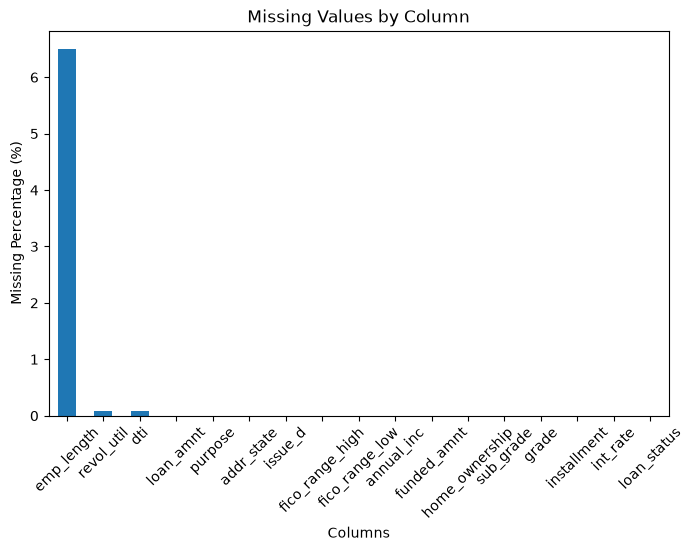

In [75]:
# Step 6.1 : Visualize Missing Values
# Display missing values as a bar chart
missing_df["Missing Percentage (%)"].plot(
    kind="bar",
    figsize=(8,5),
    title="Missing Values by Column"
)

plt.xlabel("Columns")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)

plt.show()

In [76]:
# STEP 7: Handle Missing Values

# Fill missing employment length with the most frequent value
loan_df["emp_length"] = loan_df["emp_length"].fillna(
    loan_df["emp_length"].mode()[0]
)

# Fill missing annual income with the median value
loan_df["annual_inc"] = loan_df["annual_inc"].fillna(
    loan_df["annual_inc"].median()
)

# Fill missing revolving utilization with the median value
loan_df["revol_util"] = loan_df["revol_util"].fillna(
    loan_df["revol_util"].median()
)

In [77]:
# STEP 8: Remove Duplicate Records

# Check duplicate records
loan_df.duplicated().sum()

# Remove duplicate records
loan_df = loan_df.drop_duplicates()

# Verify duplicates are removed
count = int(loan_df.duplicated().sum())

print("Verify duplicates after removing: ",count)

Verify duplicates after removing:  0


In [78]:
# STEP 9: Standardize Text Columns

# List of categorical columns to standardize
text_columns = [
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "purpose",
    "loan_status",
    "addr_state"
]

# Remove extra spaces and convert text to uppercase
for col in text_columns:
    loan_df[col] = (
        loan_df[col]
        .str.strip()
        .str.upper()
    )

In [79]:
# STEP 10: Perform Business Validation Checks

# Check if funded amount exceeds requested loan amount
loan_df[
    loan_df["funded_amnt"] >
    loan_df["loan_amnt"]
]

# Check for invalid FICO score ranges
loan_df[
    loan_df["fico_range_low"] >
    loan_df["fico_range_high"]
]

# Check for negative annual income
loan_df[
    loan_df["annual_inc"] < 0
]

# Check for negative loan amount
loan_df[
    loan_df["loan_amnt"] < 0
]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,purpose,dti,revol_util,fico_range_low,fico_range_high,issue_d,addr_state,loan_status


In [80]:
# STEP 11: Detect Outliers

# Identify all numerical columns
numeric_columns = loan_df.select_dtypes(
    include="number"
).columns

numeric_columns


Index(['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
       'annual_inc', 'dti', 'revol_util', 'fico_range_low', 'fico_range_high'],
      dtype='str')

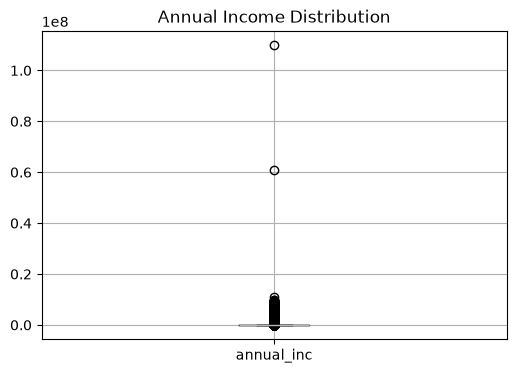

In [81]:
# Visualize annual income distribution
loan_df.boxplot(column="annual_inc", figsize=(6,4))

plt.title("Annual Income Distribution")

plt.show()

In [82]:
# STEP 12: Detect Outliers Using IQR

# Calculate Interquartile Range (IQR)
Q1 = loan_df["annual_inc"].quantile(0.25)

Q3 = loan_df["annual_inc"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

# Display outlier records
loan_df[
    (loan_df["annual_inc"] < lower_limit) |
    (loan_df["annual_inc"] > upper_limit)
]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,purpose,dti,revol_util,fico_range_low,fico_range_high,issue_d,addr_state,loan_status
6,20000.0,20000.0,36,9.17,637.58,B,B2,10+ YEARS,MORTGAGE,180000.0,DEBT_CONSOLIDATION,14.67,84.5,680.0,684.0,2015-12-01,MN,FULLY PAID
37,27500.0,27500.0,60,14.85,652.06,C,C5,10+ YEARS,MORTGAGE,195000.0,OTHER,6.79,50.9,700.0,704.0,2015-12-01,LA,FULLY PAID
74,30000.0,30000.0,36,15.77,1051.31,D,D1,2 YEARS,MORTGAGE,175000.0,HOME_IMPROVEMENT,18.50,50.3,725.0,729.0,2015-12-01,OH,FULLY PAID
165,12600.0,12600.0,60,14.85,298.77,C,C5,1 YEAR,MORTGAGE,175000.0,CREDIT_CARD,11.75,47.5,690.0,694.0,2015-12-01,MD,FULLY PAID
213,11000.0,11000.0,36,10.78,358.99,B,B4,10+ YEARS,RENT,297000.0,OTHER,12.69,61.9,670.0,674.0,2015-12-01,MD,FULLY PAID
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260665,40000.0,40000.0,60,13.49,920.19,C,C2,10+ YEARS,MORTGAGE,200000.0,DEBT_CONSOLIDATION,31.22,81.1,710.0,714.0,2016-10-01,NC,CURRENT
2260674,20000.0,20000.0,60,15.59,482.02,C,C5,9 YEARS,MORTGAGE,177000.0,RENEWABLE_ENERGY,12.36,60.8,665.0,669.0,2016-10-01,CA,FULLY PAID
2260680,40000.0,40000.0,60,15.59,964.03,C,C5,< 1 YEAR,MORTGAGE,220000.0,DEBT_CONSOLIDATION,10.88,13.3,715.0,719.0,2016-10-01,NY,FULLY PAID
2260690,29400.0,29400.0,60,13.99,683.94,C,C3,9 YEARS,MORTGAGE,180792.0,DEBT_CONSOLIDATION,22.03,85.2,705.0,709.0,2016-10-01,CA,FULLY PAID


In [83]:
# ============================================================
# STEP 13: Validate Cleaned Dataset
# ============================================================

# Verify dataset information
loan_df.info()

# Display summary statistics
loan_df.describe()

# Store validation metrics
validation_summary = {
    "Total Records": len(loan_df),
    "Total Columns": loan_df.shape[1],
    "Remaining Missing Values": int(loan_df.isnull().sum().sum()),
    "Remaining Duplicate Records": int(loan_df.duplicated().sum())
}

# Display validation summary
validation_summary

<class 'pandas.DataFrame'>
Index: 2260669 entries, 0 to 2260698
Data columns (total 18 columns):
 #   Column           Dtype         
---  ------           -----         
 0   loan_amnt        float64       
 1   funded_amnt      float64       
 2   term             int64         
 3   int_rate         float64       
 4   installment      float64       
 5   grade            str           
 6   sub_grade        str           
 7   emp_length       str           
 8   home_ownership   str           
 9   annual_inc       float64       
 10  purpose          str           
 11  dti              float64       
 12  revol_util       float64       
 13  fico_range_low   float64       
 14  fico_range_high  float64       
 15  issue_d          datetime64[us]
 16  addr_state       str           
 17  loan_status      str           
dtypes: datetime64[us](1), float64(9), int64(1), str(7)
memory usage: 327.7 MB


{'Total Records': 2260669,
 'Total Columns': 18,
 'Remaining Missing Values': 1725,
 'Remaining Duplicate Records': 0}

In [84]:
# Check remaining missing values column-wise
remaining_missing = (
    loan_df.isnull()
           .sum()
           .sort_values(ascending=False)
)

remaining_missing[remaining_missing > 0]

dti                1712
loan_amnt             1
funded_amnt           1
addr_state            1
issue_d               1
fico_range_high       1
fico_range_low        1
purpose               1
loan_status           1
home_ownership        1
sub_grade             1
grade                 1
installment           1
int_rate              1
dtype: int64

In [85]:
# Remove rows where essential fields are missing
loan_df = loan_df.dropna(
    subset=[
        "loan_amnt",
        "funded_amnt",
        "installment",
        "grade",
        "sub_grade",
        "home_ownership",
        "purpose",
        "fico_range_low",
        "fico_range_high",
        "issue_d",
        "addr_state",
        "loan_status"
    ]
)

In [86]:
# Fill missing DTI values with the median
loan_df["dti"] = loan_df["dti"].fillna(
    loan_df["dti"].median()
)

DTI: Imputed using the median because it's a skewed numerical variable and median is less sensitive to outliers.

Critical loan attributes :(loan amount, grade, loan status, FICO score, etc.) Removed records with missing values because there was only one incomplete record, and these fields are essential for downstream analysis and model training

In [ ]:
#Validate 2nd time

validation_summary = {
    "Total Records": len(loan_df),
    "Total Columns": loan_df.shape[1],
    "Remaining Missing Values": int(loan_df.isnull().sum().sum()),
    "Remaining Duplicate Records": int(loan_df.duplicated().sum())
}

validation_summary

{'Total Records': 2260668,
 'Total Columns': 18,
 'Remaining Missing Values': 0,
 'Remaining Duplicate Records': 0}

In [ ]:
# STEP 14: Save Cleaned Dataset

# Save cleaned dataset for feature engineering
loan_df.to_csv(
    "../data/processed/loan_cleaned.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


# Data Cleaning Summary

The dataset was successfully cleaned and prepared for exploratory data analysis.

## Cleaning Activities Performed

- Selected relevant business features for credit risk analysis.
- Converted loan issue date to datetime format.
- Standardized loan term to numeric values.
- Removed duplicate records.
- Imputed missing Debt-to-Income (DTI) values using the median.
- Removed records with missing values in critical business fields.
- Validated the final dataset for completeness.

## Final Dataset Summary

- Total Records: 2,260,668
- Total Features: 18
- Missing Values: 0
- Duplicate Records: 0

The cleaned dataset is now ready for feature engineering, exploratory data analysis, statistical testing, SQL analysis, and machine learning.